# Experiment 3 (Disentanglement Phase) — rho vs. jump_coupling

Before building a two-gate NN architecture meant to separate diffusive
coupling (`rho`) from jump-timing coupling (`jump_coupling`), this notebook
walks through two cheap checks run first: does the *existing* single-gate
model already conflate the two (Phase A.5), and can a *classical*
combination disentangle them instead (Phase A, then a retest with a
properly calibrated jump test)?

Full write-up: `results/experiment3_findings.md`. This notebook loads the
already-computed results from `experiments/experiment3_disentanglement.py`
and `experiments/experiment3c_bns_retest.py` and shows what they found.

**Headline: three negative-or-null results, each sharper than the last.**
Correlation beats the NN outright (Experiment 2). The existing gate doesn't
conflate jump/diffusive coupling -- but only because it's blind to jump
structure entirely (Phase A.5). And a properly calibrated classical jump
test still can't cleanly separate the two, for a specific, understood
structural reason -- not because nobody tried hard enough (Phase A retest).


In [1]:
import sys
sys.path.insert(0, "..")

import csv
import numpy as np
import matplotlib.pyplot as plt

from src.baseline import _bns_jump_flags, _naive_threshold_jump_flags

%matplotlib inline

def load_csv(path):
    with open(path) as f:
        return list(csv.DictReader(f))


## Phase A.5 — does the existing single-gate model conflate rho and jump_coupling?

A single scalar `alpha` reading off one gated mixture has no structural
reason to distinguish "assets move together because of shared diffusion"
from "assets move together because they jump at the same time" -- both just
look like "cross-sectional pathway helps." Test: hold `rho=0.5` fixed, vary
`jump_coupling` from 0.2 to 0.8, retrain, see if `alpha` moves. (Experiment
1 already showed alpha tracks `rho` at fixed `jump_coupling` -- this fills
in the other arm.)


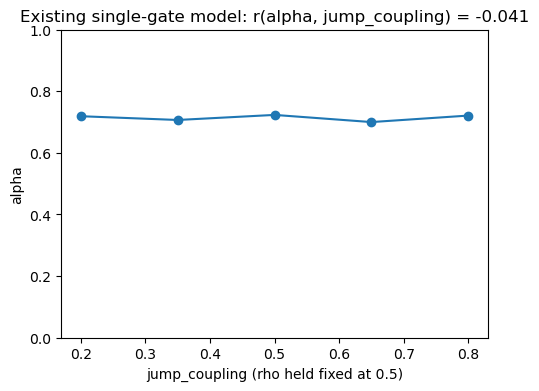

alpha values across the grid: [0.7187, 0.7065, 0.723, 0.6997, 0.7208]


In [2]:
rows = load_csv("../results/experiment3_conflation_diagnostic.csv")
jc = np.array([float(r["jump_coupling"]) for r in rows])
alpha = np.array([float(r["alpha"]) for r in rows])
r = np.corrcoef(jc, alpha)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(jc, alpha, "o-", color="C0")
ax.set_ylim(0, 1)
ax.set_xlabel("jump_coupling (rho held fixed at 0.5)")
ax.set_ylabel("alpha")
ax.set_title(f"Existing single-gate model: r(alpha, jump_coupling) = {r:.3f}")
plt.show()

print("alpha values across the grid:", alpha.round(4).tolist())


**Result: r(alpha, jump_coupling) ≈ 0**, and the values themselves are
noise-level flat. This was a genuine surprise -- the intuitive hypothesis
was that jumps (simultaneous large cross-sectional moves) would look
identical to diffusive coupling from the model's point of view and get
conflated into the same gate. Instead alpha is essentially **indifferent**
to jump structure, in either direction.

Likely cause: jump events are rare (~3-4 per path here) against thousands
of ordinary timesteps; under an MSE loss averaged over the whole panel,
jump-timing coupling gets diluted into irrelevance. This is not clean
disentanglement -- it's the aggregate loss not "seeing" jumps at all.


## Phase A — classical disentanglement baseline

Bipower variation (Barndorff-Nielsen & Shephard) estimates each asset's
diffusive variance robustly to jumps -- it uses products of *adjacent*
returns rather than squares, so an isolated jump barely moves it (a jump
appears in two products, each diluted by its typically-normal-sized
neighbor). From that, two separate correlation signals:

- **diffusive_corr**: realized correlation on the jump-scrubbed series --
  should track `rho`.
- **jump_corr**: co-occurrence correlation of binary jump-timing flags
  across assets -- should track `jump_coupling`.

The first version used a naive fixed threshold (`r_t^2 > 9 * bipower_variation`).


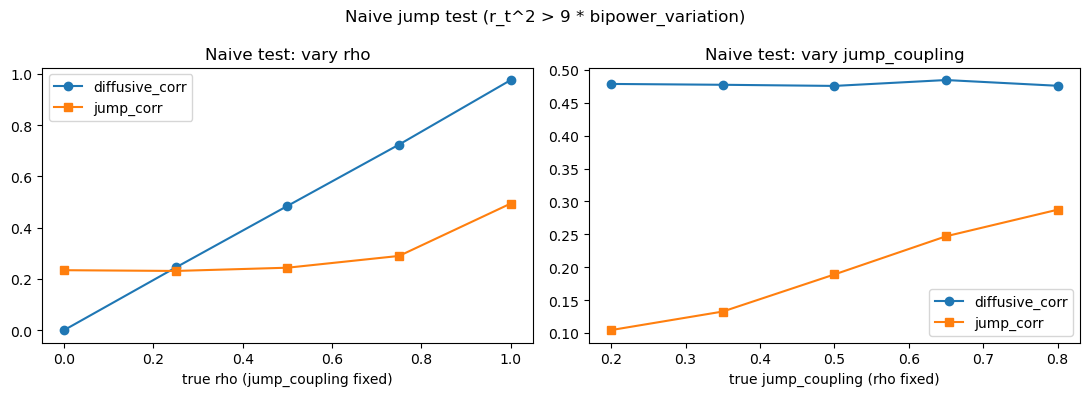

diffusive_corr: r(rho)=1.0000  r(jump_coupling)=0.0702
jump_corr:      r(jump_coupling)=0.9944  r(rho)=0.8182  <-- contamination


In [3]:
rows_c = load_csv("../results/experiment3c_bns_retest.csv")

def arm_data(method, arm):
    sub = [r for r in rows_c if r["method"] == method and r["arm"] == arm]
    if arm == "vary_rho":
        x = np.array([float(r["rho"]) for r in sub])
    else:
        x = np.array([float(r["jump_coupling"]) for r in sub])
    diff = np.array([float(r["diffusive_corr"]) for r in sub])
    jump = np.array([float(r["jump_corr"]) for r in sub])
    return x, diff, jump

rho_x, naive_diff_rho, naive_jump_rho = arm_data("naive", "vary_rho")
jc_x, naive_diff_jc, naive_jump_jc = arm_data("naive", "vary_jump_coupling")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rho_x, naive_diff_rho, "o-", label="diffusive_corr", color="C0")
axes[0].plot(rho_x, naive_jump_rho, "s-", label="jump_corr", color="C1")
axes[0].set_xlabel("true rho (jump_coupling fixed)")
axes[0].set_title("Naive test: vary rho")
axes[0].legend()

axes[1].plot(jc_x, naive_diff_jc, "o-", label="diffusive_corr", color="C0")
axes[1].plot(jc_x, naive_jump_jc, "s-", label="jump_corr", color="C1")
axes[1].set_xlabel("true jump_coupling (rho fixed)")
axes[1].set_title("Naive test: vary jump_coupling")
axes[1].legend()
plt.suptitle("Naive jump test (r_t^2 > 9 * bipower_variation)")
plt.tight_layout()
plt.show()

print(f"diffusive_corr: r(rho)={np.corrcoef(rho_x, naive_diff_rho)[0,1]:.4f}  "
      f"r(jump_coupling)={np.corrcoef(jc_x, naive_diff_jc)[0,1]:.4f}")
print(f"jump_corr:      r(jump_coupling)={np.corrcoef(jc_x, naive_jump_jc)[0,1]:.4f}  "
      f"r(rho)={np.corrcoef(rho_x, naive_jump_rho)[0,1]:.4f}  <-- contamination")


`diffusive_corr` disentangles cleanly. `jump_corr` is badly contaminated by
`rho` -- notice it rises sharply in the left panel even though
`jump_coupling` was held fixed there.


## Phase A retest — is this just an uncalibrated threshold?

Hypothesis: the naive test is a fixed multiplier, not a calibrated
statistical test -- it has no defined false-positive rate, so nothing stops
co-occurring false positives (inevitable once `rho` correlates the
underlying series) from producing a spurious `jump_corr`-vs-`rho`
relationship.

Fix: a Barndorff-Nielsen & Shephard / Huang-Tauchen **ratio jump test**,
normalized by realized tripower quarticity -- a properly calibrated
z-statistic under the null of "no jump in this block," with a known,
controllable false-positive rate, rather than an arbitrary cutoff.

**First, an isolated sanity check** (no rho involved at all): does the
calibrated test actually behave better than the naive one on its own?


In [4]:
rng = np.random.default_rng(0)
pure_noise = rng.normal(0, 1, 2000)
naive_fp = _naive_threshold_jump_flags(pure_noise).sum()
bns_fp = _bns_jump_flags(pure_noise).sum()
print(f"Pure Gaussian noise, n=2000, zero true jumps:")
print(f"  naive test flags: {naive_fp}")
print(f"  bns test flags:   {bns_fp}")

injected = pure_noise.copy()
jump_idx = [500, 1000, 1500]
injected[jump_idx] += 15.0
recovered = np.where(_bns_jump_flags(injected))[0].tolist()
print(f"\n3 injected jumps at {jump_idx} -> bns recovers: {recovered}")


Pure Gaussian noise, n=2000, zero true jumps:
  naive test flags: 7
  bns test flags:   0

3 injected jumps at [500, 1000, 1500] -> bns recovers: [500, 1000, 1500]


Confirmed: the calibrated test genuinely fixes the false-positive-rate
problem in isolation (0 spurious flags vs. several for naive), and still
recovers real injected jumps exactly. **Now the real question: does this
fix the contamination on the actual disentanglement grid?**


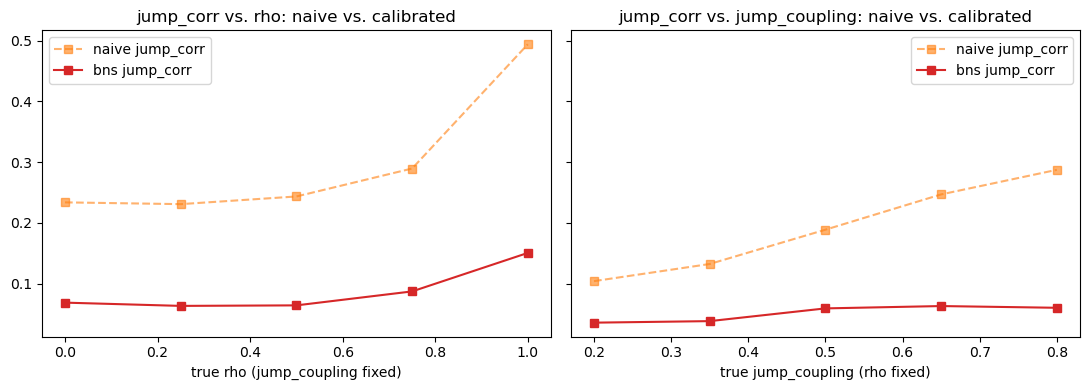

Contamination r(jump_corr, rho):  naive=0.8182   bns=0.8031
jump_corr magnitude range:        naive=[0.231, 0.494]   bns=[0.064, 0.151]


In [5]:
bns_diff_rho_x, bns_diff_rho, bns_jump_rho = arm_data("bns", "vary_rho")
bns_jc_x, bns_diff_jc, bns_jump_jc = arm_data("bns", "vary_jump_coupling")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].plot(rho_x, naive_jump_rho, "s--", label="naive jump_corr", color="C1", alpha=0.6)
axes[0].plot(bns_diff_rho_x, bns_jump_rho, "s-", label="bns jump_corr", color="C3")
axes[0].set_xlabel("true rho (jump_coupling fixed)")
axes[0].set_title("jump_corr vs. rho: naive vs. calibrated")
axes[0].legend()

axes[1].plot(jc_x, naive_jump_jc, "s--", label="naive jump_corr", color="C1", alpha=0.6)
axes[1].plot(bns_jc_x, bns_jump_jc, "s-", label="bns jump_corr", color="C3")
axes[1].set_xlabel("true jump_coupling (rho fixed)")
axes[1].set_title("jump_corr vs. jump_coupling: naive vs. calibrated")
axes[1].legend()
plt.tight_layout()
plt.show()

contam_naive = np.corrcoef(rho_x, naive_jump_rho)[0, 1]
contam_bns = np.corrcoef(bns_diff_rho_x, bns_jump_rho)[0, 1]
print(f"Contamination r(jump_corr, rho):  naive={contam_naive:.4f}   bns={contam_bns:.4f}")
print(f"jump_corr magnitude range:        naive=[{naive_jump_rho.min():.3f}, {naive_jump_rho.max():.3f}]"
      f"   bns=[{bns_jump_rho.min():.3f}, {bns_jump_rho.max():.3f}]")


**The calibrated test roughly halves the raw jump_corr values** (it's
correctly filtering out more spurious co-movement overall) **but the
contamination correlation barely moves.** Better calibration fixed the
false-positive *rate*; it did not fix the *contamination*.

### Why this isn't a calibration bug

At `rho -> 1`, each asset's diffusive shock is dominated by the shared
common factor (idiosyncratic weight `sqrt(1-rho) -> 0`). A properly
calibrated per-asset test can be exactly as rare and well-behaved as
intended and *still* fire simultaneously across assets whenever that shared
factor happens to draw an extreme value -- because at high rho the assets'
returns are, by construction, nearly identical draws of the same random
variable. A single large, purely diffusive, shared draw and a genuine
coordinated jump are close to observationally identical at this sampling
frequency (daily, `dt=1/252`) -- both are "large, simultaneous,
cross-sectionally correlated moves." The classical jump-detection
literature's usual identification argument (diffusive increments shrink
like `sqrt(dt)`, jump sizes don't) needs much higher-frequency sampling than
daily bars to bite; it doesn't help here.

Both the naive and calibrated tests also share the same structural blind
spot: they decide "is this a jump" **per asset, independently**, then
correlate the resulting flags after the fact. The confound lives in the
*joint* cross-sectional pattern, not in any single asset's marginal
distribution -- no per-asset threshold, however well-calibrated, can fix a
problem that only exists in the relationship *between* assets.


## What would actually need to differ, if Phase B is ever scoped

The generator's own structure gives a real, exploitable difference between
the two mechanisms that no per-asset test can see:

- A shared **diffusive** draw moves every asset in a *fixed, known ratio* --
  proportional to each asset's own `sigma_i`, since
  `diffusion_i = sigma_i * sqrt(rho) * z_common + idio`. A deterministic,
  rank-1 pattern.
- A common **jump**, by contrast, draws an *independent* jump size per
  asset even when the timing is shared (per `jump_diffusion_generator.py`'s
  own docstring). The cross-sectional *shape* of the move looks
  unstructured, not proportional to vol.

Telling these apart requires looking at the **pattern across the whole
cross-section jointly** -- is this vector of simultaneous moves proportional
to known vol ratios, or does it look like independent draws? -- not
thresholding each asset's own return in isolation. That's exactly the kind
of joint, whole-cross-section computation an attention-based pathway is
structurally suited to do, and a per-asset statistical test structurally is
not. A real candidate design for Phase B's cross-sectional pathway, if it
gets built -- not another per-asset outlier detector wearing a neural net,
and combined with Phase A.5's finding: it would need a jump-specific
training objective (predicting jump occurrence directly), not raw-return
MSE, or it will hit the same dilution problem the existing gate did.


## Verdict

Three negative-or-null results now, but of increasing specificity:

1. **Experiment 2**: the NN doesn't beat a two-line correlation calculation
   on the diffusive coupling question at all.
2. **Phase A.5**: the existing single-gate NN doesn't conflate jump and
   diffusive coupling -- but only because it's blind to jump structure
   entirely, not because it disentangles them.
3. **Phase A retest**: a properly calibrated classical jump test still
   can't cleanly separate the two, for a specific, understood structural
   reason (per-asset testing can't resolve a joint cross-sectional
   confound) -- not because nobody tried hard enough classically.

(3) rules out "just use a better classical test" and leaves a specific,
falsifiable hypothesis for what would actually need to differ
architecturally. That's a narrower, sharper case for Phase B than existed
before this diagnostic -- worth scoping deliberately if pursued, rather than
as a default "try the NN" step. Full reasoning: `results/experiment3_findings.md`.
